In [1]:
import numpy as np
import json, h5py, os
import argparse
from scipy import signal

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# plt.style.use("classic")
# plt.style.use("seaborn-v0_8-paper")
from matplotlib import cycler as mpl_cycler
import matplotlib.colors as mcolors
# Set figure size and resolution
mpl.rcParams['figure.figsize'] = (3*1.5, 3)   # typical column width in inches
# mpl.rcParams['figure.dpi'] = 300              # high resolution for publication

# Set font properties
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'Times']
mpl.rcParams['font.size'] = 12                # base font size
mpl.rcParams['text.usetex'] = True           # set True if you have LaTeX installed and want LaTeX rendering
mpl.rcParams['text.latex.preamble'] = r'\usepackage{mathptmx}'
# mpl.rcParams['mathtext.rm'] = 'Times New Roman' # when usetex is set False
# mpl.rcParams['mathtext.fontset'] = 'stix'

# Axes settings
mpl.rcParams['axes.linewidth'] = 0.8          # thinner lines for axes
mpl.rcParams['axes.labelsize'] = 12           # axis label font size
mpl.rcParams['axes.titlesize'] = 12           # title font size
mpl.rcParams['axes.grid'] = False             # often grid is turned off for clean figures

# Tick settings
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 4          # tick length
mpl.rcParams['ytick.major.size'] = 4
mpl.rcParams['xtick.minor.size'] = 2
mpl.rcParams['ytick.minor.size'] = 2
mpl.rcParams['xtick.labelsize'] = 12           # tick label font size
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams["xtick.minor.visible"] = False
mpl.rcParams["ytick.minor.visible"] = False

# Legend settings
mpl.rcParams['legend.frameon'] = False        # no legend frame
mpl.rcParams['legend.fontsize'] = 10

# Line settings
mpl.rcParams['lines.linewidth'] = 1.2         # general line width
mpl.rcParams['lines.markersize'] = 4          # marker size

# Save figure settings (optional, for high-quality output)
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['savefig.bbox'] = 'tight'

In [3]:
ROOT_PATH = f"{os.getenv("HOME")}/Documents/QC_whip/code-2d/"

## Entanglement entropy in 2D

In [4]:
def gen_res_str(args):
    dir_str = f"{ROOT_PATH}/{args.dir}/"
    file_str = f"2D_sqr_Whip_L{args.L}_Chi{args.chi}"
    if (args.dir=="EE_MPS_2D"):
        file_str += f"_a{args.a}_b{args.b}"
    return dir_str, file_str

def read_res_data(args):
    dir_str, file_str = gen_res_str(args)
    with h5py.File(dir_str+file_str+".jld2", "r") as fl:
        svns = fl["saved_svn"][()]
        evns = fl["saved_evn"][()]
        maxdims =fl["saved_linkdim"][()]
        thetas = fl["saved_thetas"][()]
    return {"THETAS": thetas, "vN_entropy": svns, 
            "MaxDims": maxdims, "vN_spectrum": evns}

def read_res_zzdata(args):
    dir_str, file_str = gen_res_str(args)
    with h5py.File(dir_str+file_str+"_ZZ.jld2", "r") as fl:
        zzs = fl["saved_zz"][()]
        thetas = fl["saved_thetas"][()]
    return {"THETAS": thetas, "ZZS": zzs}

In [5]:
config_dict = {"L": 10,"chi": 500, "dir": "EE_MPS_2D"
            }
args = argparse.Namespace(**config_dict)
parser = argparse.ArgumentParser()

parser.add_argument('--a', type=int)
parser.add_argument('--b', type=int)
parser.parse_args(args=['--a', "0"], namespace=args)
parser.parse_args(args=['--b', "200"], namespace=args)

Namespace(L=10, chi=500, dir='EE_MPS_2D', a=0, b=200)

In [6]:
Ls = np.array("2 4 6 8 10 12".split(), dtype=int)

In [7]:
Data = []
for L in Ls:
    args.L = L
    if L == 12:
        args.chi = 2048
        args.a = 0
        args.b = 40
    else:
        args.chi = 2000

    Data.append(read_res_data(args))

Text(0, 0.5, 'Entanglement entropy $S$')

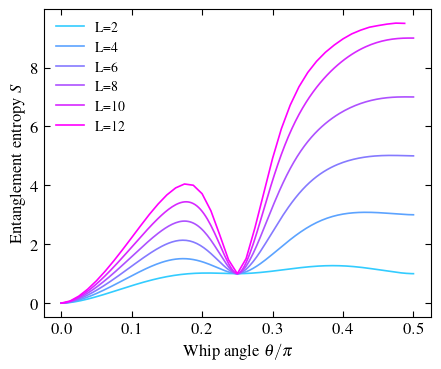

In [10]:
# plot the entropy as a function of theta

fig = plt.figure(figsize=(5,4))
ax = plt.subplot(1,1,1)

color_values = np.linspace(0.2, 1, len(Ls))
mmap = plt.cm.cool(color_values)
mmrk = ["none"] * len(Ls)
mlbl = ["L=%i"%N for N in Ls]
# for (i,N) in enumerate(Ls):
    # if 4<N<8: mlbl[i]=None
    # if N==6: mlbl[i]=" "

for i in range(len(Ls)):
    a = Data[i]
    if Ls[i]==12:
        plt.plot(a["THETAS"][:-1]/np.pi, a["vN_entropy"][:-1], '-', color=mmap[i], marker=mmrk[i], label=mlbl[i])
    else:
        plt.plot(a["THETAS"]/np.pi, a["vN_entropy"], '-', color=mmap[i], marker=mmrk[i], label=mlbl[i])

plt.legend()
plt.xlabel(r"Whip angle $\theta/\pi$")
plt.ylabel(r"Entanglement entropy $S$")
# plt.savefig("figure/Entanglement entropy paths.svg")

Text(0.95, 0.95, '$L\\times L=12\\times12$')

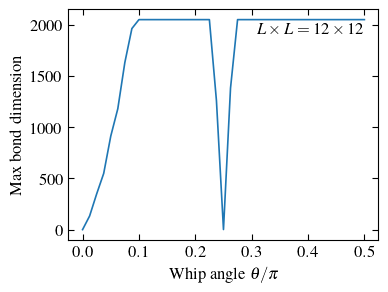

In [9]:
plt.figure(figsize=(4,3))
ax = plt.subplot(1,1,1)
plt.plot(Data[-1]["THETAS"]/np.pi, Data[-1]["MaxDims"])
plt.ylabel("Max bond dimension")
plt.xlabel(r"Whip angle $\theta/\pi$")
plt.text(0.95,0.95,r"$L\times L=%i\times%i$"%(Ls[-1],Ls[-1]), va = 'top', ha = 'right', transform = ax.transAxes)

In [196]:
# Store the EE data
entropy_data = {}

for i in range(len(Ls)):
    a = Data[i]
    entropy_data[f"L{Ls[i]}-THETA"] = a["THETAS"].tolist()
    entropy_data[f"L{Ls[i]}-vN_entropy"] = a["vN_entropy"].tolist()
    entropy_data[f"L{Ls[i]}-MaxDims"] = a["MaxDims"].tolist()

with open(f"./{args.dir}/2D_sqr_Entropy.json", "w") as f:
    json.dump(entropy_data, f)

Maximum

In [22]:
maxlocs = []
maxvals = []
xall, yall = [], []
for i in range(len(Ls)):
    a = Data[i]
    if Ls[i]==10:
        x = a["THETAS"]
    else:
        x = a["THETAS"]
    y = a["vN_entropy"]
    xall.append(x)
    yall.append(y)
    loc, _ = signal.find_peaks(y)
    if len(loc) == 1:
        
        maxlocs.append(np.array([x[loc[0]], np.nan]))
        maxvals.append(np.array([y[loc[0]], np.nan]))
    else:
        maxlocs.append(x[loc[0:2]])
        maxvals.append(y[loc[0:2]])
print("Max locs:", maxlocs)
maxlocs = np.asarray(maxlocs)
maxvals = np.asarray(maxvals)

Max locs: [array([0.65188048, 1.20951317]), array([0.54192473, 1.35873882]), array([0.54192473, 1.46869457]), array([0.54977871, 1.53152642]), array([0.5576327 , 1.55508836])]


[[0.2075 0.1725 0.1725 0.175  0.1775]
 [0.385  0.4325 0.4675 0.4875 0.495 ]]


Text(0, 0.5, '$\\theta/\\pi$')

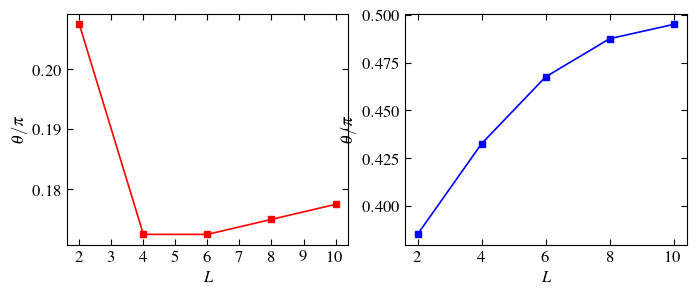

In [23]:
print(maxlocs.T/np.pi)

plt.figure(figsize=(8,3))
ax1 = plt.subplot(1,2,1)
ax1.plot(Ls,maxlocs[:,0]/np.pi,'-sr')
plt.xlabel(r"$L$")
plt.ylabel(r"$\theta/\pi$")
ax2 = plt.subplot(1,2,2)
ax2.plot(Ls,maxlocs[:,1]/np.pi,'-sb')
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.xlabel(r"$L$")
plt.ylabel(r"$\theta/\pi$")

In [24]:
a = 0
b = None
mcls = ['b','k','k','b']
mlabels = ["quantum peak", "Clifford peak"]
for i in range(2):
    ydata = maxvals[:,i]
    print(ydata)
    if i==1:
        b = -1
    else:
        b = None
    popt,pcov = curve_fit(fitfunc1, Ls[a:b], ydata[a:b])
    print(popt, np.diag(pcov))
    plt.plot(Ls, fitfunc1(Ls, *popt),color=mcls[i],lw=1.)
    plt.plot(Ls, ydata,'o',mfc="white",color=mcls[i],ms=6,label=mlabels[i])
plt.xlabel("Lattice size $L$")
plt.ylabel("Entanglement entropy $S$")
plt.legend()
plt.savefig("figure/Entanglement entropy peaks.svg")
plt.show()

[1.02218253 1.50984597 2.13656946 2.78563474 3.4405001 ]


NameError: name 'curve_fit' is not defined

# plot the entropy spectrum as a function of theta

In [11]:
idx = Ls.tolist().index(12)
a = Data[idx]
print(f'----{Ls[idx]}x{Ls[idx]}----')


# fig = plt.figure(figsize  =(5,4))
# ax = plt.subplot(1,1,1)

n_lambda = []
lambda_max = []
ub = 0
for i in range(len(a["THETAS"])):
    ev_i = a["vN_spectrum"][:,i]
    ev_i[ev_i<1e-16] = 100
    nan_idx = ev_i!=100
    ev_i = ev_i[nan_idx]

    sorted_ev_i = np.sort(ev_i).tolist()
    n_lambda.append(len(ev_i))
    if len(sorted_ev_i)==1:
        lambda_max.append([[sorted_ev_i[-1]]])
    elif len(sorted_ev_i)==2:
        lambda_max.append([[sorted_ev_i[-1],sorted_ev_i[-2]]])
    else:
        ub = max(-1-len(sorted_ev_i),-6)
        lambda_max.append([sorted_ev_i[ub:][::-1]])

    ev_i = - 2 * np.log(ev_i)
    color_values = np.linspace(0.2, 1, len(ev_i)+1)
    mmap = plt.cm.GnBu(color_values)[1:]
    th_i = [a["THETAS"][i]/np.pi for j in range(len(ev_i))]
    lw_i = [0.0,0.0] + [0 for j in range(len(ev_i)-2)]
    # plt.scatter(th_i, ev_i, color=mmap, s=4, marker='o', edgecolors="k", linewidths=lw_i)
    
# plt.text(0.95,0.95,r"$L\times L=%i\times%i$"%(Ls[idx],Ls[idx]), va = 'top', ha = 'right', transform = ax.transAxes)
# plt.xlabel(r"$\theta/\pi$")
# plt.ylabel(r"$-\log_2(\lambda)$")
# plt.show()

----12x12----


In [12]:
ub = max([len(x[0]) for x in lambda_max])
for i in range(len(lambda_max)):
    nzero = (ub-len(lambda_max[i][0]))
    lambda_max[i] = lambda_max[i][0] + [0]*nzero
    # print(lambda_max[i])

----12x12----


/var/folders/hc/vtxmhrys2hg7xgqdp4448wxc0000gn/T/ipykernel_82384/158664769.py:12: RuntimeWarning: divide by zero encountered in log
  y = -2*np.log(lambda_max[:,i])


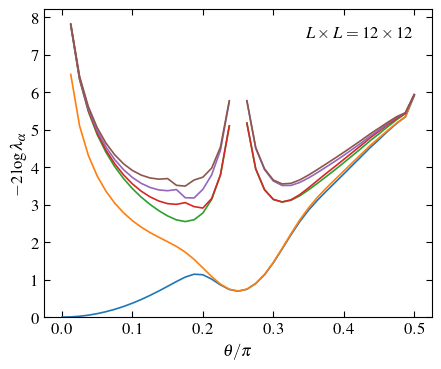

In [13]:
# # plot the entropy spectrum as a function of theta
fig = plt.figure(figsize=(5,4))
ax = plt.subplot(1,1,1)

# for (i,N) in enumerate(Ls):
    # if 4<N<8: mlbl[i]=None
    # if N==6: mlbl[i]=" "
a = Data[idx]
print(f'----{Ls[idx]}x{Ls[idx]}----')
lambda_max = np.array(lambda_max)
for i in range(ub):
    y = -2*np.log(lambda_max[:,i])
    plt.plot(a["THETAS"]/np.pi, y)

plt.ylim(0,)
plt.text(0.95,0.95,r"$L\times L=%i\times%i$"%(Ls[idx],Ls[idx]), va = 'top', ha = 'right', transform = ax.transAxes)
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$-2\log\lambda_\alpha$")
plt.show()

In [147]:
# Store the lowest three energy levels
spectrum_data = {}
if os.path.exists(f"./{args.dir}/2D_sqr_Spectrum.json"):
    print("read from old file")
    with open(f"./{args.dir}/2D_sqr_Spectrum.json", "r") as f:
        spectrum_data = json.load(f)

spectrum_data[f"L{Ls[idx]}-THETA"] = (a["THETAS"]/np.pi).tolist()
for i in range(ub):
    spectrum_data[f"L{Ls[idx]}-{i}"] = lambda_max[:,i].tolist()

with open(f"./{args.dir}/2D_sqr_Spectrum.json", "w") as f:
    json.dump(spectrum_data, f)

read from old file


Area between the first level and the second level

In [31]:
dtheta = a["THETAS"][1]-a["THETAS"][0]
ydiff = -np.log2(lambda_max[1:,1]) - -np.log2(lambda_max[1:,2])
mid = len(ydiff)//2
np.sum(ydiff[0:mid])*dtheta, np.sum(ydiff[mid:])*dtheta

(np.float64(2.4442562333349254), np.float64(0.0549799739857735))

In [116]:
Ls = np.array([2, 4, 6, 8, 10])
area1 = np.array([2.5128194642614106, 2.473225905049905, 2.457282159348177, 2.4489504963756374, 2.4442562333349254])
area2 = np.array([0.44259645121825614, 0.18577067712197423, 0.11079618013153625, 0.07512211193804294, 0.0549799739857735])

In [117]:
from scipy.optimize import curve_fit

def fitfunc1(x,a,const):
    return a*x + const

def fitfunc2(x,a,b,const):
    return a*x**2 + b*x + const

def fitfunc3(x,a,b,c,const):
    return a*x**3 + b*x**2 +c*x + const

def fitfuncp(x,a,const):
    return const + x**a

fit area1: [-0.0868093   0.22408543  2.42249343] [0.00798691 0.00497007 0.00057649]
fit area2: [ 0.38696319  0.73740981 -0.02284034] [0.00761594 0.00473923 0.00054971]


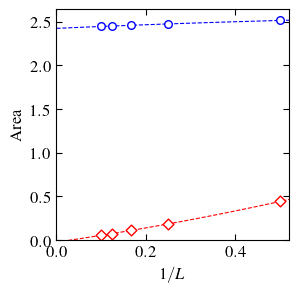

In [118]:
# # plot the entropy spectrum as a function of theta
fig = plt.figure(figsize=(3,3))
ax = plt.subplot(1,1,1)

plt.scatter(1/Ls, area1, marker='o', color='w', edgecolor="b", zorder=2,s=30)
plt.scatter(1/Ls, area2, marker='D', color='w', edgecolor="r", zorder=2,s=30)

xpath = np.linspace(0,0.52,101)
popt1, perr1 = curve_fit(fitfunc2, 1/Ls, area1)
popt2, perr2 = curve_fit(fitfunc2, 1/Ls, area2)
print("fit area1:", popt1, perr1.diagonal()**0.5)
print("fit area2:", popt2, perr2.diagonal()**0.5)
plt.plot(xpath, fitfunc2(xpath, *popt1), '--', lw=0.8, zorder=1, color='b')
plt.plot(xpath, fitfunc2(xpath, *popt2), '--', lw=0.8, zorder=1, color='r')

plt.xlim(0,0.52)
plt.ylim(0,)
plt.xlabel(r"$1/L$")
plt.ylabel("Area")
plt.show()

# extrapolate the energy level directly

In [173]:
with open(f"./{args.dir}/2D_sqr_Spectrum.json", "r") as f:
    spectrum_data = json.load(f)

In [188]:
# extrapolate
xs = np.array([4,6,8,10])
y1inf = []
y2inf = []
xth = spectrum_data[f"L2-THETA"]
for i in range(1,len(xth)):
    y1s = [spectrum_data[f"L{l}-0"][i] for l in xs]
    y2s = [spectrum_data[f"L{l}-1"][i] for l in xs]
    y1s = -np.log2(y1s)
    y2s = -np.log2(y2s)
    if np.std(y1s)<1e-8:
        popt, perr = curve_fit(fitfunc1, 1/xs, y1s)
    else:
        popt, perr = curve_fit(fitfunc1, 1/xs, y1s)
    y1inf.append([popt[-1], perr[-1,-1]])
    if np.std(y2s)<1e-8:
        popt, perr = curve_fit(fitfunc1, 1/xs, y2s)
    else:
        popt, perr = curve_fit(fitfunc1, 1/xs, y2s)
    y2inf.append([popt[-1], perr[-1,-1]])
y1inf = np.asarray(y1inf)
y2inf = np.asarray(y2inf)

print(y1inf[99,:], y2inf[99,:])
if np.inf in y1inf[:,1]:
    print("0")
    y1inf[np.where(np.inf==y1inf[:,1])[0],1] = 0.0
if np.inf in y2inf[:,1]:
    print("1")
    y2inf[np.where(np.inf==y2inf[:,1])[0],1] = 0.0

[0.5 inf] [4.99999998e-01 4.19862609e-19]
0


/var/folders/hc/vtxmhrys2hg7xgqdp4448wxc0000gn/T/ipykernel_57402/460115392.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, perr = curve_fit(fitfunc1, 1/xs, y1s)


/var/folders/hc/vtxmhrys2hg7xgqdp4448wxc0000gn/T/ipykernel_57402/3353139817.py:9: RuntimeWarning: divide by zero encountered in log2
  y2 = -np.log2(spectrum_data[f"L{l}-1"])


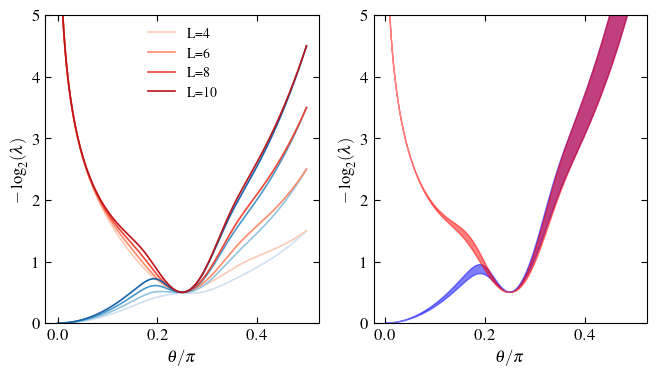

In [189]:
fig_spec = plt.figure(figsize=(12,4))

ax1 = plt.subplot(1,3,1)
color_values = np.linspace(0.2, 1, 5)
mmap1 = plt.cm.Blues(color_values)
mmap2 = plt.cm.Reds(color_values)
for (i,l) in enumerate([4,6,8,10]):
    y1 = -np.log2(spectrum_data[f"L{l}-0"])
    y2 = -np.log2(spectrum_data[f"L{l}-1"])
    plt.plot(spectrum_data[f"L{l}-THETA"], y1, color=mmap1[i],zorder=0)
    plt.plot(spectrum_data[f"L{l}-THETA"], y2, color=mmap2[i],zorder=0, label="L=%i"%l)
plt.legend()

ax2 = plt.subplot(1,3,2)
plt.fill_between(xth[1:], y1inf[:,0]-y1inf[:,1]**0.5, y1inf[:,0]+y1inf[:,1]**0.5, alpha=0.5, color="b")
plt.fill_between(xth[1:], y2inf[:,0]-y2inf[:,1]**0.5, y2inf[:,0]+y2inf[:,1]**0.5, alpha=0.5, color="r")

for ax in [ax1,ax2]:
    ax.set_ylim(0,5)
    ax.set_ylabel(r"$-\log_2(\lambda)$")
    ax.set_xlabel(r"$\theta/\pi$")

In [190]:
spectrum_data["Linf-THETA"] = xth[1:]
spectrum_data["Linf-0-FIT"] = (y1inf[:,0]).tolist()
spectrum_data["Linf-0-STD"] = (y1inf[:,1]**0.5).tolist()
spectrum_data["Linf-1-FIT"] = (y2inf[:,0]).tolist()
spectrum_data["Linf-1-STD"] = (y2inf[:,1]**0.5).tolist()

with open(f"./{args.dir}/2D_sqr_Spectrum.json", "w") as f:
    json.dump(spectrum_data, f)

near the transition point

In [62]:
xs = np.array([6,8,10,12,14,16])
y1th = []
y2th = []
ths = [0.49,0.51] #spectrum_data[f"L12-THETA"]
for theta in ths:
    thloc = [spectrum_data[f"L{l}-THETA"].index(theta) for l in xs]
    print(thloc)
    y1s = [spectrum_data[f"L{xs[i]}-1"][thloc[i]] for i in range(len(thloc))]
    y2s = [spectrum_data[f"L{xs[i]}-2"][thloc[i]] for i in range(len(thloc))]
    y1s = -np.log2(y1s)
    y2s = -np.log2(y2s)
    y1th.append(y1s)
    y2th.append(y2s)
y1th = np.asarray(y1th)
y2th = np.asarray(y2th)

[196, 196, 196, 0, 0, 0]
[204, 204, 204, 8, 8, 8]


[[0.00869389 0.0044982  0.00232863 0.00120595 0.00062482 0.00032357]
 [0.00743119 0.00361102 0.00175566 0.00085406 0.00041563 0.00020251]]
fit left: [ 2.61976521e+00 -2.27493882e-04] [0.022395   0.00018374]
fit right: [ 2.70435981e+00 -2.89330996e-04] [0.01665073 0.00011603]


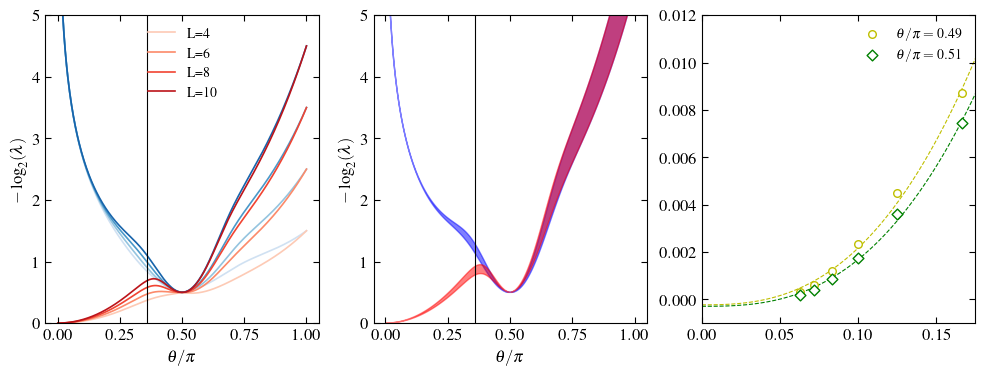

In [63]:
dyth = y1th - y2th
print(dyth)

ax3 = fig_spec.add_subplot(1,3,3)

ax3.scatter(1/xs, dyth[0,:], marker='o', color='w', edgecolor="y", zorder=2,s=30, label=r"$\theta/\pi=0.49$")
ax3.scatter(1/xs, dyth[1,:], marker='D', color='w', edgecolor="g", zorder=2,s=30, label=r"$\theta/\pi=0.51$")

xpath = np.linspace(0,1.05*max(1/xs),101)
popt1, perr1 = curve_fit(fitfuncp, 1/xs[:], dyth[0,:])
popt2, perr2 = curve_fit(fitfuncp, 1/xs[:], dyth[1,:])
print("fit left:", popt1, perr1.diagonal()**0.5)
print("fit right:", popt2, perr2.diagonal()**0.5)
ax3.plot(xpath, fitfuncp(xpath, *popt1), '--', lw=0.8, zorder=1, color='y')
ax3.plot(xpath, fitfuncp(xpath, *popt2), '--', lw=0.8, zorder=1, color='g')

ax3.set_xlim(0,np.max(xpath))
ax3.set_ylim(-0.001,0.012)
ax3.legend()

for ax in [ax1,ax2]:
    ax.vlines(0.36, ymin=0, ymax=5, lw=0.8, color='k')
fig_spec

# Schmidt gap

In [ ]:
xs = np.array([4,6,8,10])
thetas = []
dyth = []
for l in xs:
    ths = spectrum_data[f"L{l}-THETA"]
    y1s = spectrum_data[f"L{l}-1"]
    y2s = spectrum_data[f"L{l}-2"]
    
    dyth.append(np.asarray([y2s[i] - y1s[i] for i in range(len(y1s))]))
    thetas.append(np.array(ths))

: 

(0.0, 5.0)

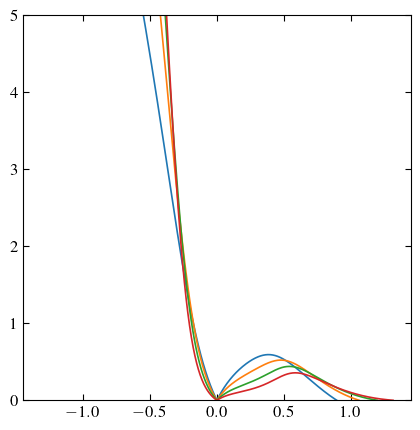

In [95]:
fig = plt.figure(figsize=(5,5))
ax = plt.subplot(1,1,1)

for i in range(len(xs)):
    l = xs[i]
    plt.plot((thetas[i]-0.5)*(l**0.42), dyth[i]*(l**1.5),'-')
    # plt.plot((thetas[i]-0.5)*(l**3.0), dyth[i] * (l**0.3),'-o')
plt.ylim(0,5)

# ZZ coupling

In [7]:
args.L = 10
args.chi = 1024
zzdata = read_res_zzdata(args)

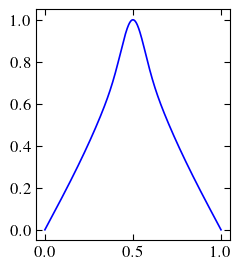

In [10]:
fig = plt.figure(figsize=(2.5,3))
ax = plt.subplot(1,1,1)

plt.plot(zzdata["THETAS"]/np.pi,np.abs(zzdata["ZZS"])*4,'-b')

In [21]:
with open(f"{ROOT_PATH}/data/2D_sqr_Whip_L{args.L}_Chi{args.chi}_classical.json", "w") as f:
    data = {"L":args.L, "CHI":args.chi,
            "i1": (args.L-1)*args.L+1,
            "i2": (args.L-1)*args.L+2,
            "THETAS": zzdata["THETAS"].tolist(),
            "ZZS": (np.abs(zzdata["ZZS"])*4).tolist()}
    json.dump(data, f, indent=2)

## Change $\chi$

In [77]:
Data = []
L = 20
chis = [64, 128]
for chi in chis:
    args.L = L
    args.chi = chi
    Data.append(read_res_data(args))

Text(0, 0.5, '$S$')

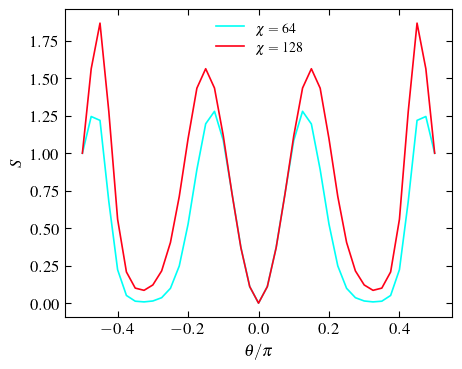

In [86]:
# plot the entropy as a function of theta

fig = plt.figure(figsize=(5,4))
ax = plt.subplot(1,1,1)

color_values = np.linspace(0.5, 1, len(chis))
mmap = plt.cm.hsv(color_values)
mmrk = ["none"] * len(chis)
mlbl = [r"$\chi=%i$"%x for x in chis]
for (i,N) in enumerate(chis):
    if 4<N<8: mlbl[i]=None
    if N==6: mlbl[i]=" "

for i in range(len(chis)):
    a = Data[i]
    plt.plot(a["THETAS"]/np.pi, a["vN_entropy"], '-', color=mmap[i], marker=mmrk[i], label=mlbl[i])

plt.legend()
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$S$")